In [3]:
import torch
from dinosaw.helpers import ModelTypes, model_names, get_models,get_features, add_custom_font
from dinosaw.utils import do_2D_pca

import numpy as np
from PIL import Image

import matplotlib.pyplot as plt

SEED = 100001
torch.manual_seed(SEED)
np.random.seed(SEED)

DEVICE = 'cuda:0'
half = True

/home/pawlo/miniforge3/envs/minimal_dinosaw/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
enabled_models: tuple[ModelTypes, ...] = ('alibi_dv2_coco', 'nope')
models = get_models(enabled_models, "../../trained_models", DEVICE, half)

## test

In [ ]:
SF = 0.7
# img_fname = "frankfurt.jpg" 
img_fname = "NMC_2D_crop.png" 
# img_fname = "cells.jpg" # very good example
img_fname = "bio_micro9.jpg" # maybe good in pca 3-6


interpolation = Image.LANCZOS

_img = Image.open(f"../images/{img_fname}").convert("RGB")
_img = _img.resize((int(SF * _img.width), int(SF * _img.height)), interpolation)

In [6]:
features = {}
features_reduced = {}
for model_key in enabled_models:
    model = models[model_key]
    feats = get_features(model, _img, False, False, device=DEVICE, to_half=half)
    features[model_key] = feats
    

In [22]:
i = 0
for model_key in enabled_models:
    feat = features[model_key]
    features_reduced[model_key] = do_2D_pca(feat.copy(), 9, pre_norm="std", post_norm='minmax')[:, :, i*3:i*3+3]

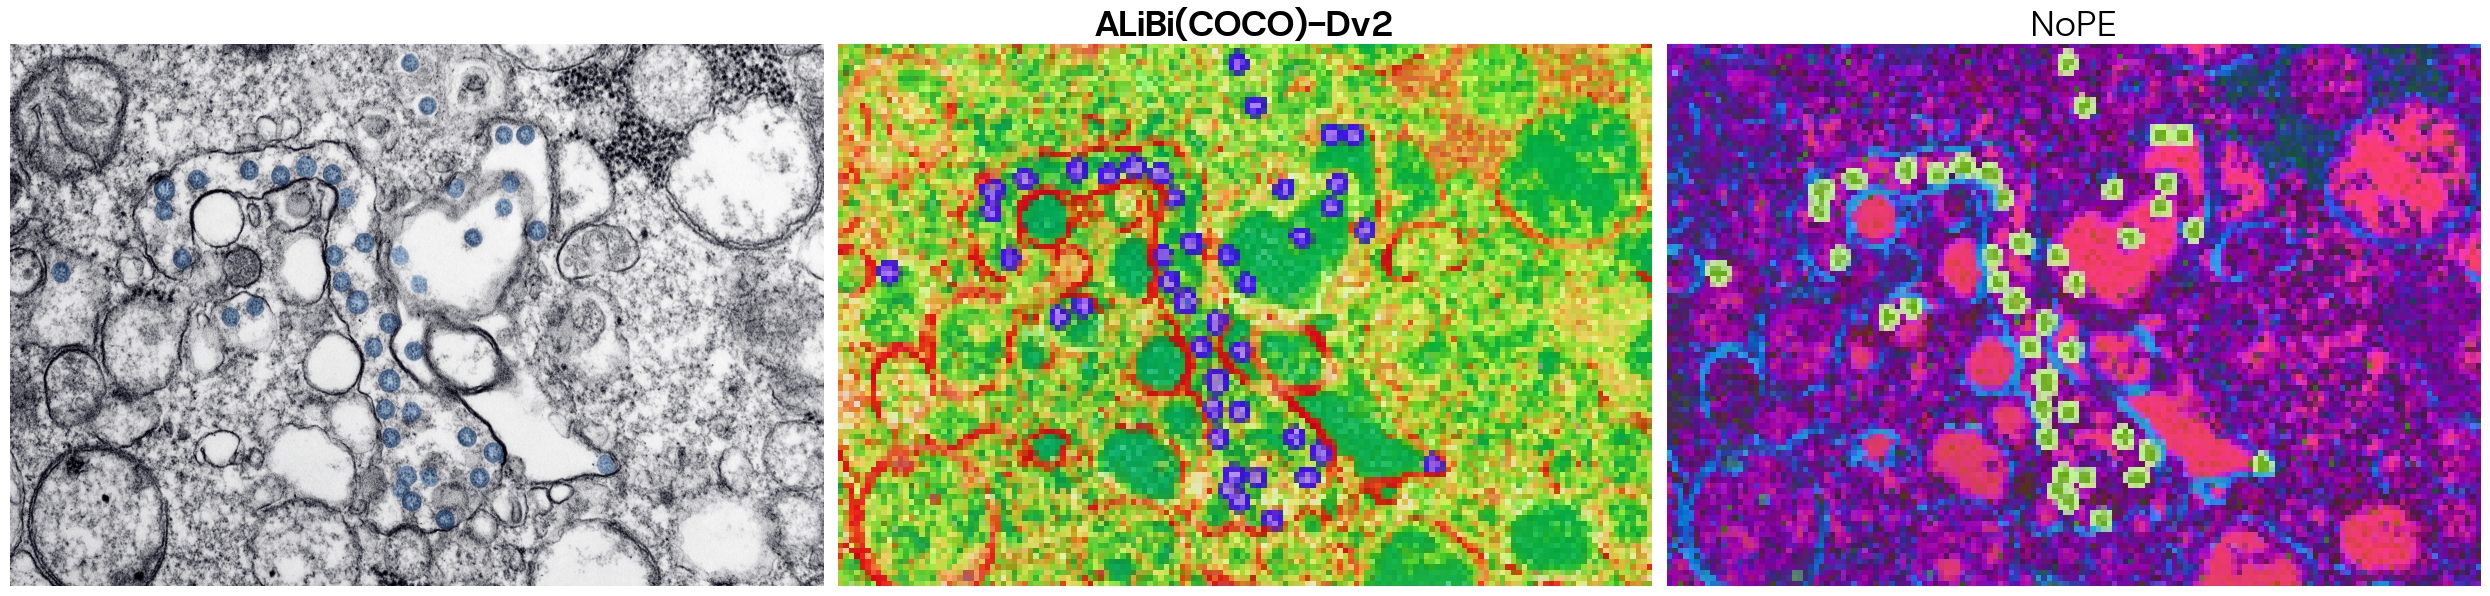

In [ ]:
# %%capture
FLIP = False
fig, axs = plt.subplots(nrows=1, ncols=1 + len(enabled_models), figsize=(25, 25))
add_custom_font("resources/fonts")
axs[0].imshow(_img)
axs[0].set_axis_off()
for i, model_key in enumerate(enabled_models):
    feats_red = features_reduced[model_key]
    ax = axs[i + 1]
    ax.set_title(model_names[model_key], fontsize=26, fontweight = "bold" if "alibi" in model_key else None)
    ax.imshow(np.flip(feats_red, axis=2)) if FLIP else ax.imshow(feats_red)
    ax.set_axis_off()
plt.tight_layout()
# fig.savefig(f"saved/S03_{img_fname[:-4]}_SF_{SF}.jpeg", dpi=300, bbox_inches='tight', pil_kwargs={'optimize': True})

## paper plot

In [5]:
SF = (1, 0.7)
imgs = ("cells.jpg", "bio_micro9.jpg")

In [ ]:
channel_group = 0
features, features_reduced = [], []
for img_file, sf_ in zip(imgs, SF):
    for model_key in enabled_models:
        model = models[model_key]
        img_path = f'../images/{img_file}'
        img = Image.open(img_path).convert('RGB')
        img = img.resize((int(sf_ * img.width), int(sf_ * img.height)), Image.LANCZOS)
        feats = get_features(model, img, device=DEVICE, channel_last=False, to_half=half)#.cpu()
        features.append(feats)
        features_reduced.append(do_2D_pca(feats, (channel_group+1)*3, pre_norm="std", post_norm='minmax')[:, :, channel_group*3:channel_group*3+3])

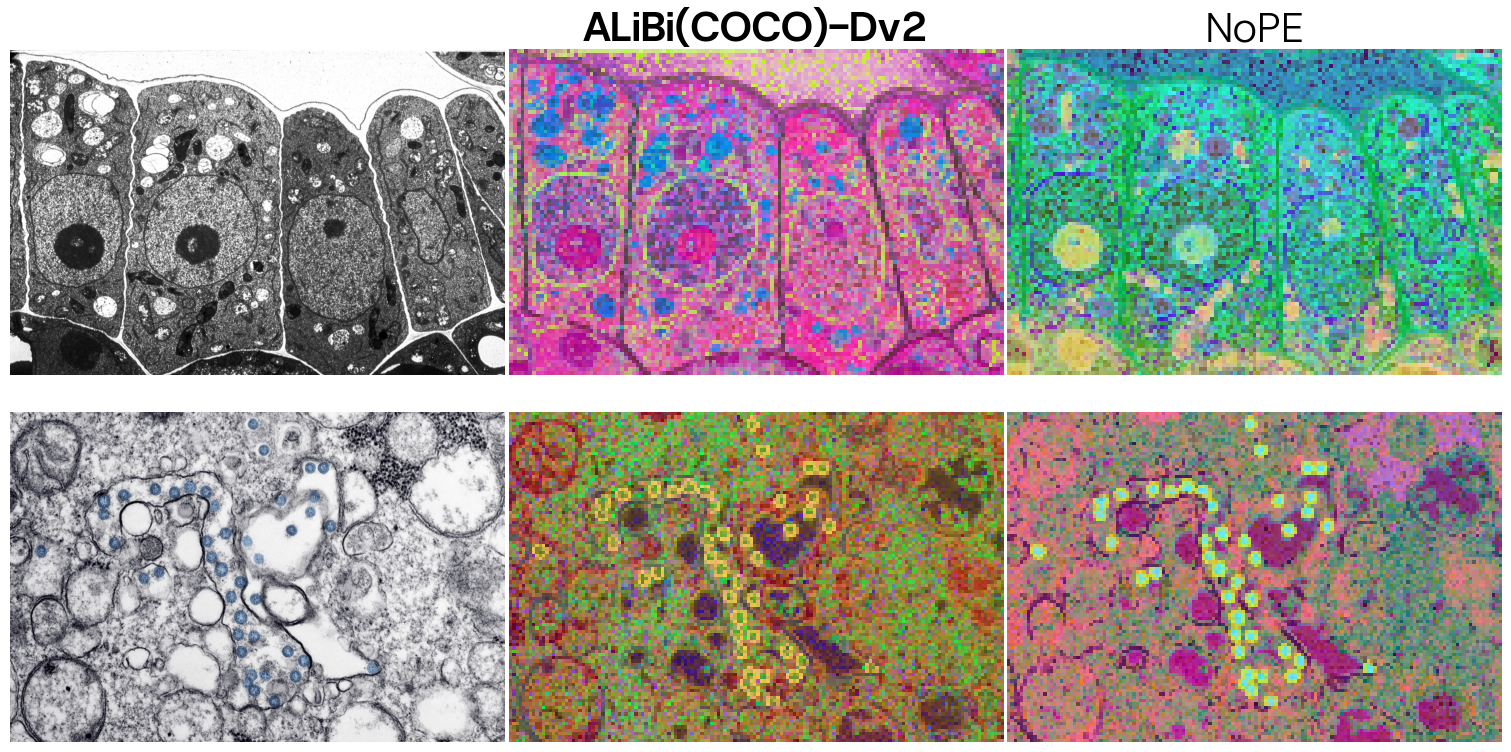

In [ ]:
from matplotlib.gridspec import GridSpec
FS = 30
NCOLS=1 + len(enabled_models)
NROWS = len(imgs)
FLIP = False
# fig, axs = plt.subplots(nrows=NROWS, ncols=NCOLS, figsize=(25, 25), gridspec_kw={"hspace":0.5})
fig = plt.figure(figsize=(5*NCOLS, 4*NROWS))
gs = GridSpec(NROWS, NCOLS, figure=fig)



counter = 0
for idx, feat in enumerate(features_reduced):
    if idx %2 == 0:
        ax = fig.add_subplot(gs[counter//3, counter%3])
        ax.imshow(Image.open(f"../images/{imgs[idx//2]}").convert("RGB"))
        ax.set_axis_off()
        counter +=1
    ax = fig.add_subplot(gs[counter//3, counter%3])
    ax.imshow(feat)
    if counter == 1:
        ax.set_title(model_names[enabled_models[counter-1]], fontsize=FS, fontweight="bold")
    if counter == 2:
        ax.set_title(model_names[enabled_models[counter-1]], fontsize=FS)
    ax.set_axis_off()
    counter+=1
fig.tight_layout(pad=0.3)